In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)



In [2]:
df=pd.read_csv("C:/Users/ASUS/OneDrive/Desktop/Employee_Attrition_Prediction_HR/DATA/WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [9]:
df.Gender.value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

In [10]:
# for binary applying for categorical data having two values (y/n)


In [11]:
df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})
df.head(3)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [12]:
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [13]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [14]:
df=df.join(pd.get_dummies(df['BusinessTravel'])).drop('BusinessTravel',axis=1)


In [15]:
df=df.join(pd.get_dummies(df['Department'])).drop('Department',axis=1)

In [16]:
df=df.join(pd.get_dummies(df['EducationField'],prefix='Eductaion')).drop('EducationField',axis=1)

In [17]:
df=df.join(pd.get_dummies(df['JobRole'],prefix='Role')).drop('JobRole',axis=1)

In [18]:
df=df.join(pd.get_dummies(df['MaritalStatus'],prefix='Status')).drop('MaritalStatus',axis=1)

In [19]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single
0,41,1,1102,1,2,1,1,2,Female,94,...,False,False,False,False,False,True,False,False,False,True
1,49,0,279,8,1,1,2,3,Male,61,...,False,False,False,False,True,False,False,False,True,False
2,37,1,1373,2,2,1,4,4,Male,92,...,True,False,False,False,False,False,False,False,False,True
3,33,0,1392,3,4,1,5,4,Female,56,...,False,False,False,False,True,False,False,False,True,False
4,27,0,591,2,1,1,7,1,Male,40,...,True,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,Male,41,...,True,False,False,False,False,False,False,False,True,False
1466,39,0,613,6,1,1,2062,4,Male,42,...,False,False,False,False,False,False,False,False,True,False
1467,27,0,155,4,3,1,2064,2,Male,87,...,False,False,True,False,False,False,False,False,True,False
1468,49,0,1023,2,3,1,2065,4,Male,63,...,False,False,False,False,False,True,False,False,True,False


In [20]:
df=df.map(lambda x : 1 if x is True else 0 if x is False else x)

In [21]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,...,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single
0,41,1,1102,1,2,1,1,2,Female,94,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,2,3,Male,61,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,4,Male,92,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,5,4,Female,56,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,7,1,Male,40,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,2061,3,Male,41,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,1,2062,4,Male,42,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,1,2064,2,Male,87,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,1,2065,4,Male,63,...,0,0,0,0,0,1,0,0,1,0


In [22]:
df=df.drop('EmployeeNumber',axis=1)

In [23]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,...,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single
0,41,1,1102,1,2,1,2,Female,94,3,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,1,3,Male,61,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,1,4,Male,92,2,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,1,4,Female,56,3,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,1,Male,40,3,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,1,3,Male,41,4,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,1,4,Male,42,2,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,1,2,Male,87,4,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,1,4,Male,63,2,...,0,0,0,0,0,1,0,0,1,0


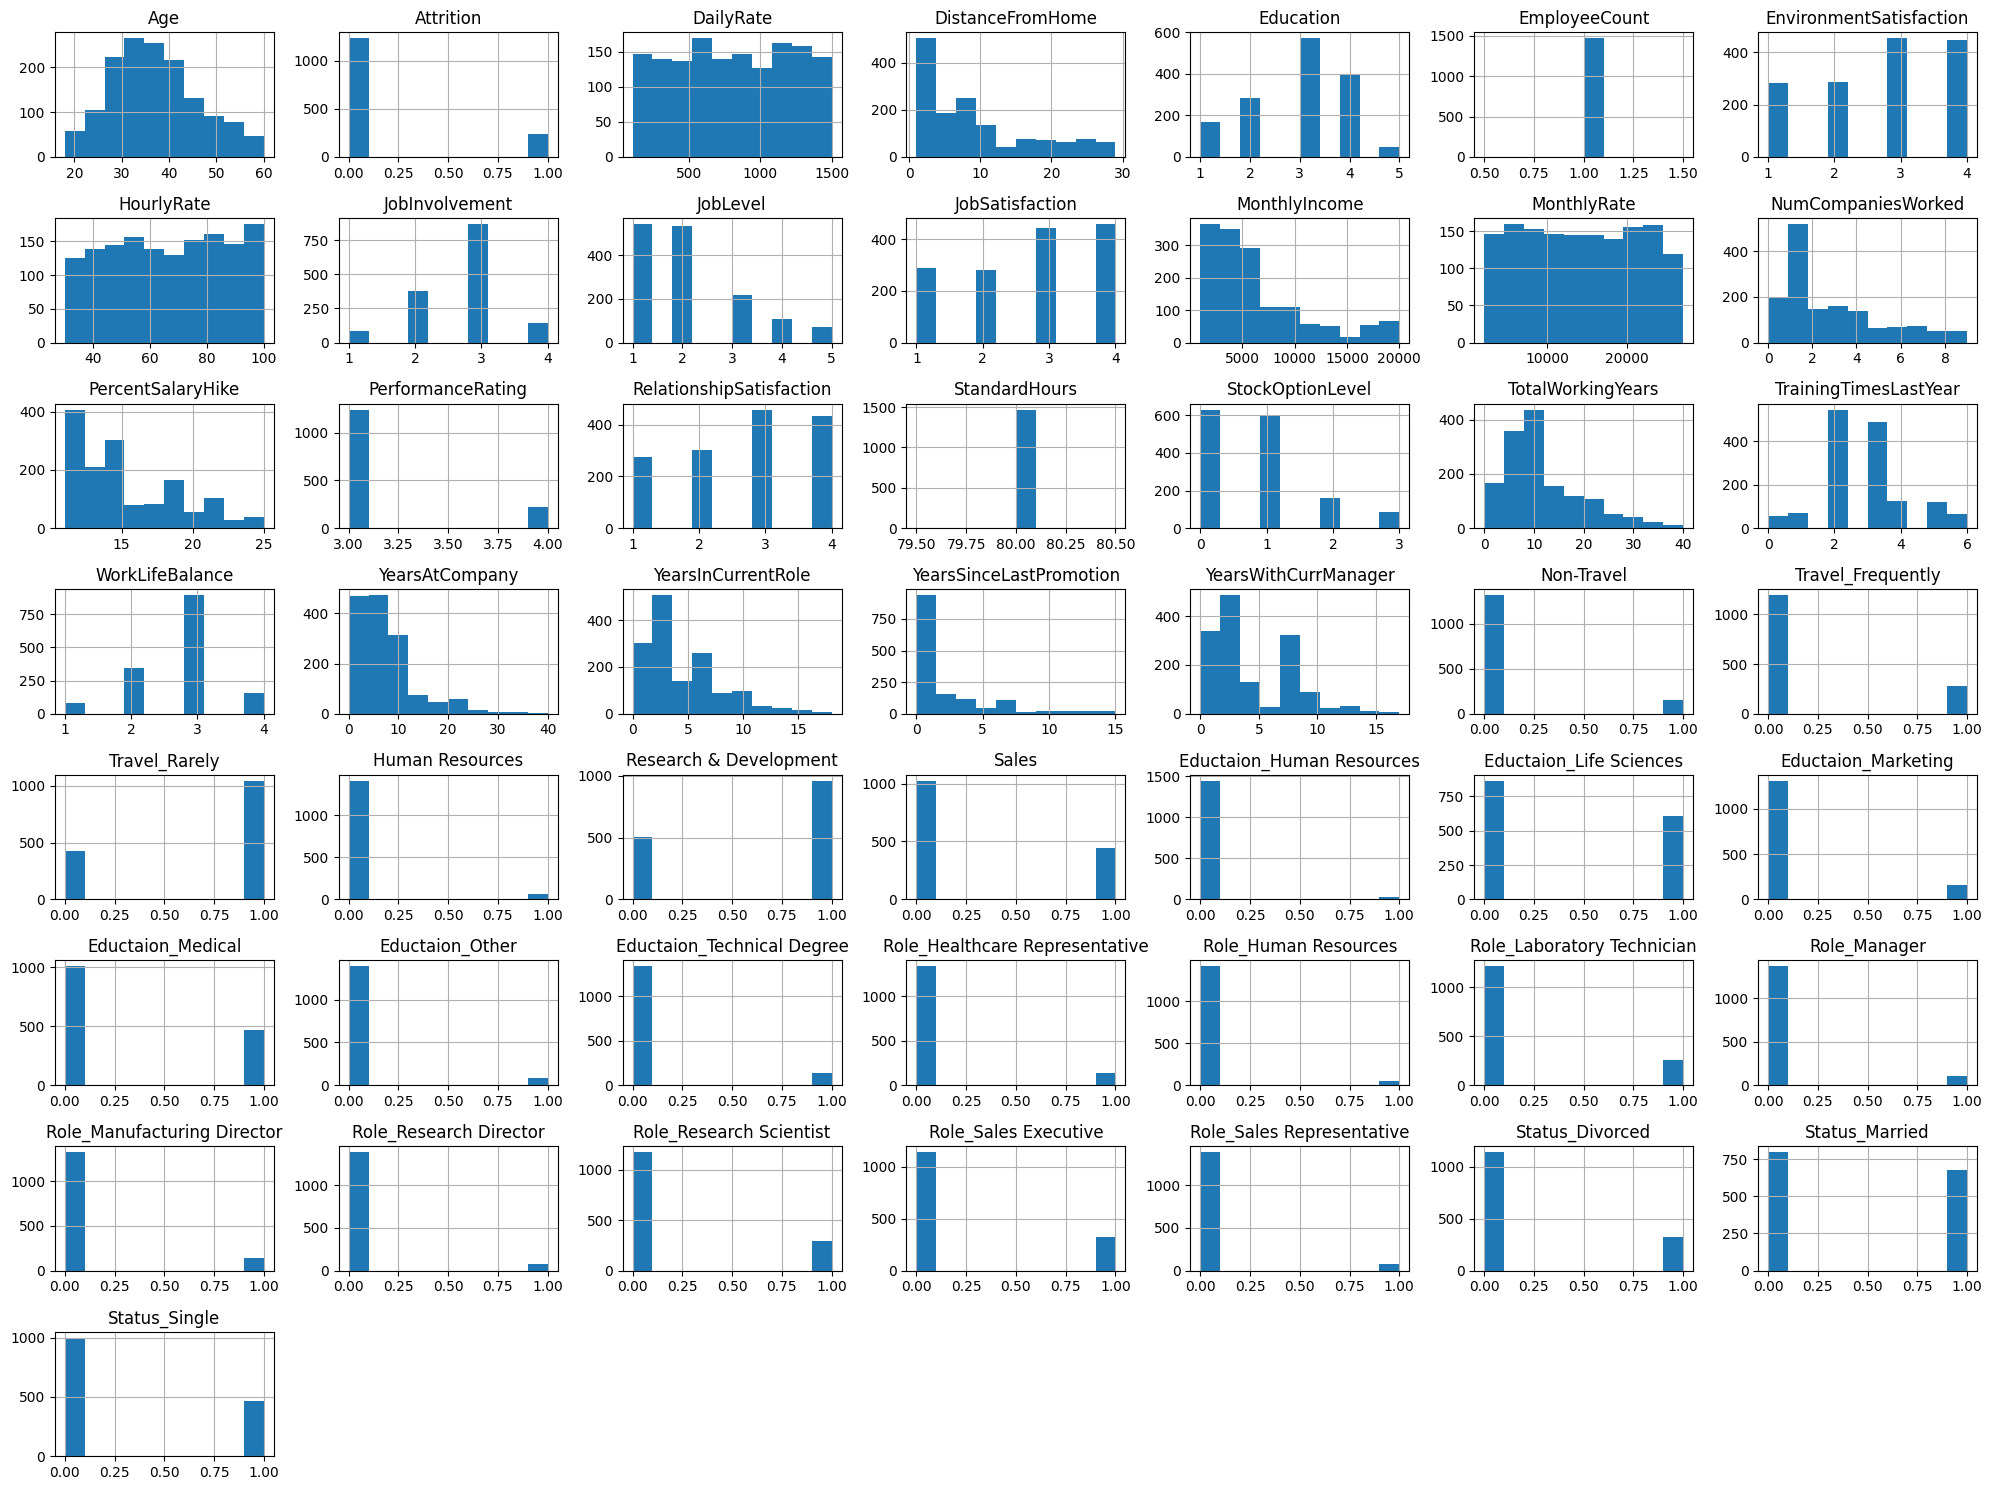

In [24]:
df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

In [25]:
df=df.drop(['EmployeeCount','Over18','StandardHours'],axis=1)

In [26]:
df

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,Role_Laboratory Technician,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single
0,41,1,1102,1,2,2,Female,94,3,2,...,0,0,0,0,0,1,0,0,0,1
1,49,0,279,8,1,3,Male,61,2,2,...,0,0,0,0,1,0,0,0,1,0
2,37,1,1373,2,2,4,Male,92,2,1,...,1,0,0,0,0,0,0,0,0,1
3,33,0,1392,3,4,4,Female,56,3,1,...,0,0,0,0,1,0,0,0,1,0
4,27,0,591,2,1,1,Male,40,3,1,...,1,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,884,23,2,3,Male,41,4,2,...,1,0,0,0,0,0,0,0,1,0
1466,39,0,613,6,1,4,Male,42,2,3,...,0,0,0,0,0,0,0,0,1,0
1467,27,0,155,4,3,2,Male,87,4,2,...,0,0,1,0,0,0,0,0,1,0
1468,49,0,1023,2,3,4,Male,63,2,2,...,0,0,0,0,0,1,0,0,1,0


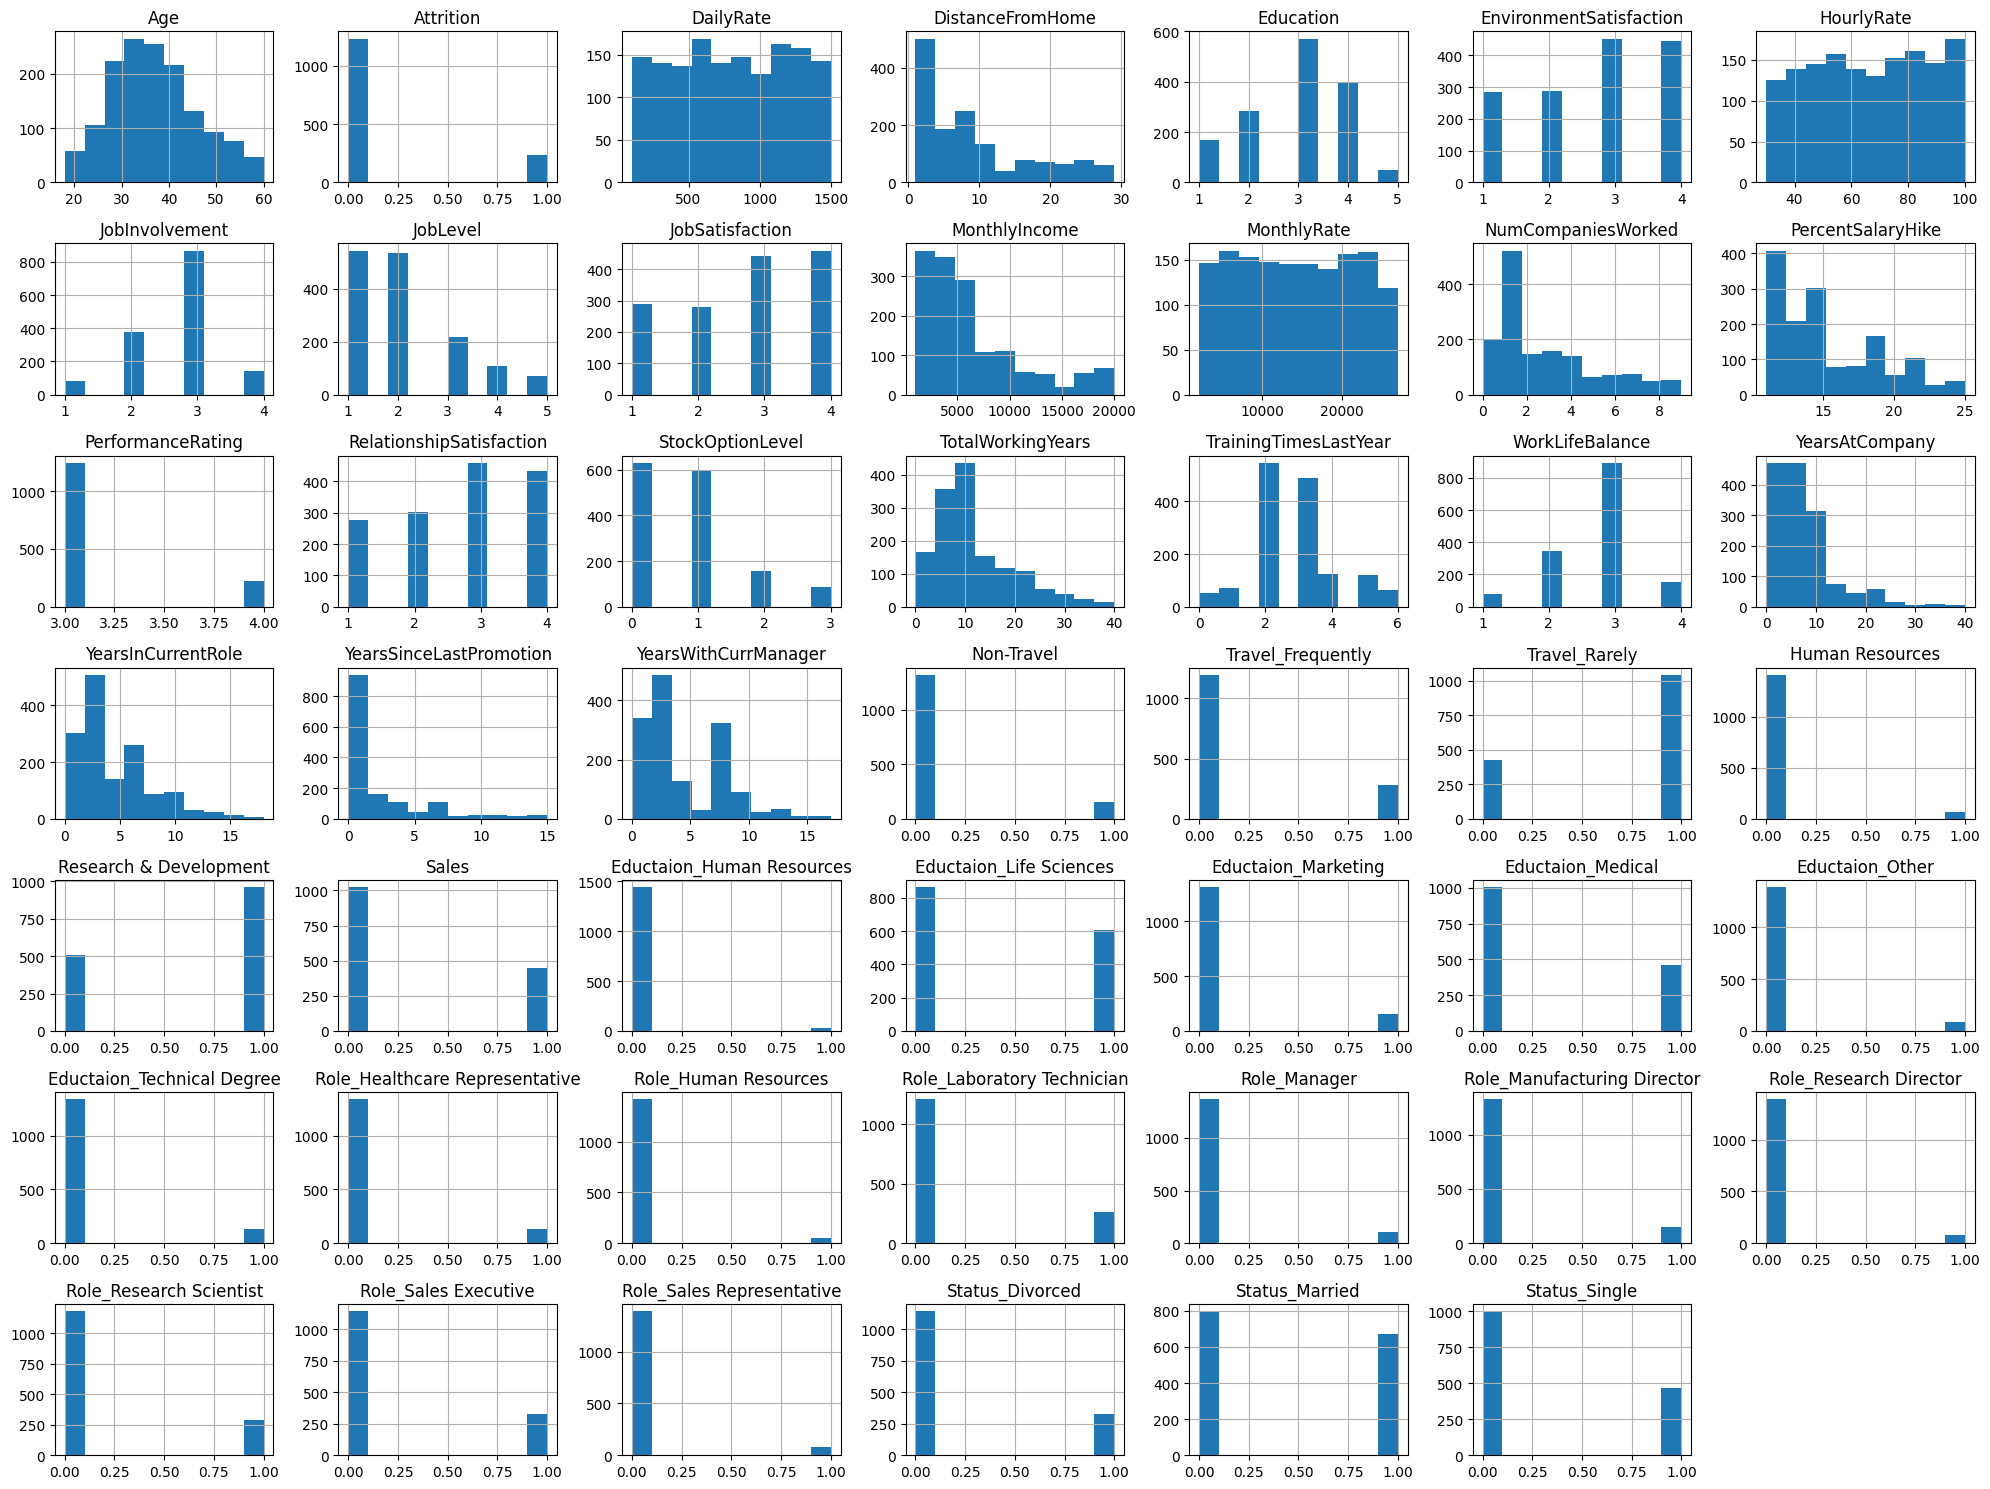

In [27]:
df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

### MODEL TRAINING


In [28]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

x= df.drop('Attrition', axis=1)
y=df['Attrition']
x = pd.get_dummies(x, drop_first=True)
x_train,x_test,y_train,y_test=train_test_split(x, y, test_size = 0.2)

model = RandomForestClassifier(n_jobs=-1)
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [29]:
pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [30]:
model.score(x_test,y_test)

0.8775510204081632

In [31]:
sort_importance=dict(sorted(zip(model.feature_names_in_,model.feature_importances_),key=lambda x:x[1],reverse=True ))

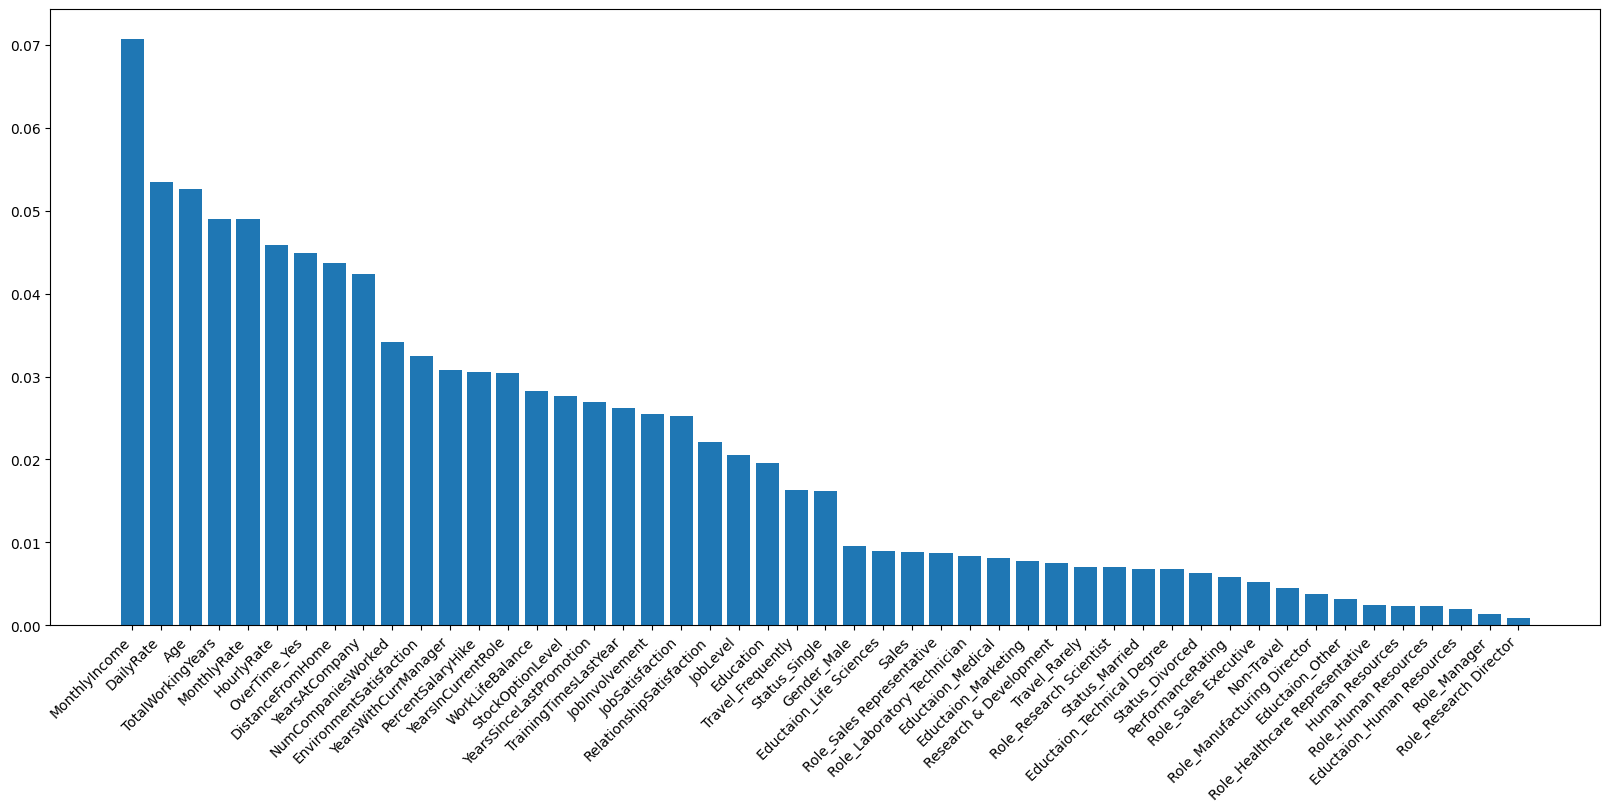

In [32]:
plt.figure(figsize=(20,8))
plt.bar(sort_importance.keys(),sort_importance.values())
plt.xticks(rotation=45,ha='right')
plt.show()

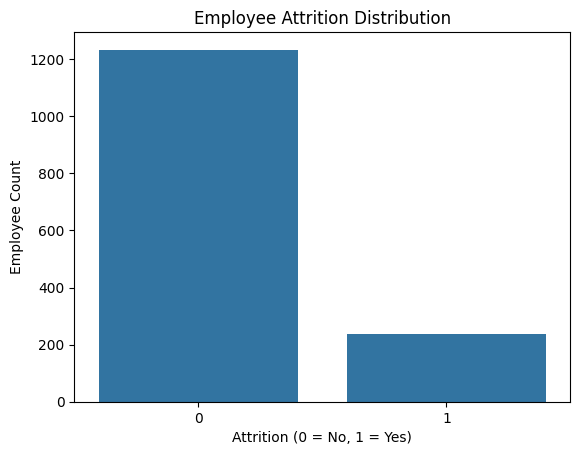

In [33]:
## is attrition is balanced or imbalanced
sns.countplot(x='Attrition', data=df)
plt.title('Employee Attrition Distribution')
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Employee Count')
plt.show()

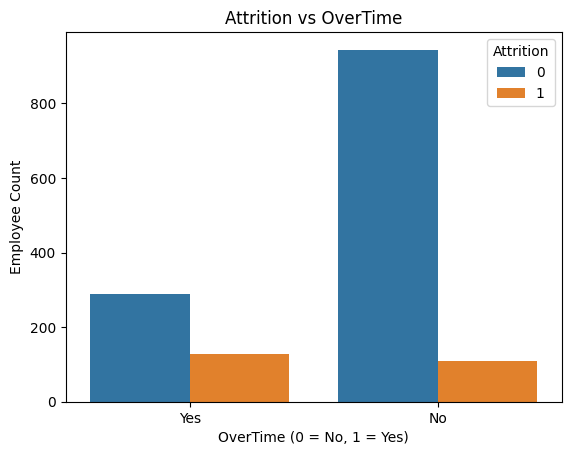

In [34]:
### mworking overtime increase attrition risk

sns.countplot(x='OverTime', hue='Attrition', data=df)
plt.title('Attrition vs OverTime')
plt.xlabel('OverTime (0 = No, 1 = Yes)')
plt.ylabel('Employee Count')
plt.show()

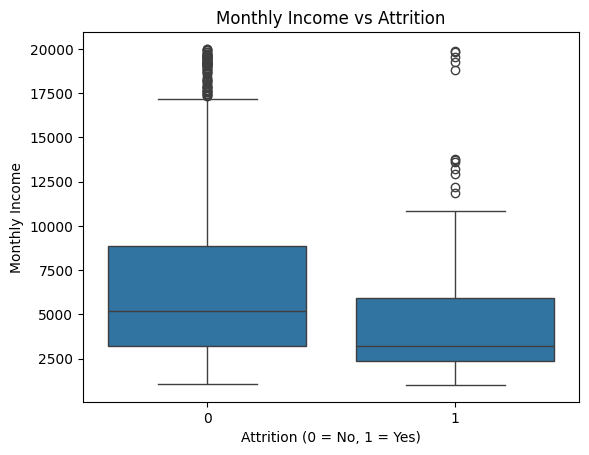

In [35]:
## salary a factor in employee attrition

sns.boxplot(x='Attrition', y='MonthlyIncome', data=df)
plt.title('Monthly Income vs Attrition')
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Monthly Income')
plt.show()


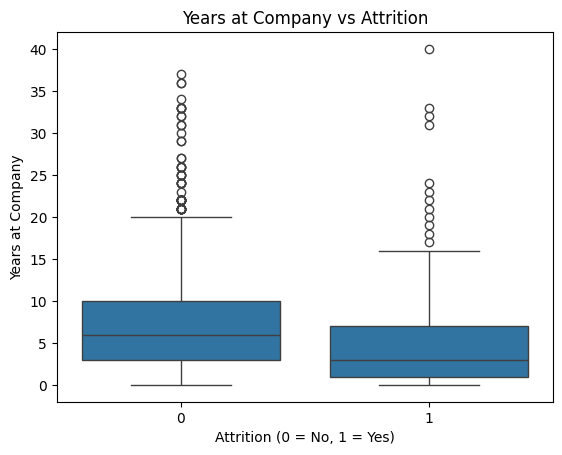

In [36]:
## employee tenure affect attrition

sns.boxplot(x='Attrition', y='YearsAtCompany', data=df)
plt.title('Years at Company vs Attrition')
plt.xlabel('Attrition (0 = No, 1 = Yes)')
plt.ylabel('Years at Company')
plt.show()

#### Stratified sampling ensures attrition distribution is preserved across train and test sets.

In [39]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [45]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

#### Logistic Regression

In [46]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(x_train, y_train)

y_pred_log = log_model.predict(x_test)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.8639455782312925
Precision: 0.7692307692307693
Recall: 0.2127659574468085
[[244   3]
 [ 37  10]]


C:\Users\ASUS\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Random Forest

In [49]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8401360544217688
Precision: 0.5
Recall: 0.06382978723404255
[[244   3]
 [ 44   3]]


### Feature Importance

In [50]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

JobSatisfaction             0.071534
Age                         0.061081
RelationshipSatisfaction    0.055130
DailyRate                   0.049361
Gender                      0.047340
TrainingTimesLastYear       0.046768
MonthlyIncome               0.044569
Status_Single               0.043666
DistanceFromHome            0.039866
YearsInCurrentRole          0.038854
dtype: float64

### Plot Feature Importance

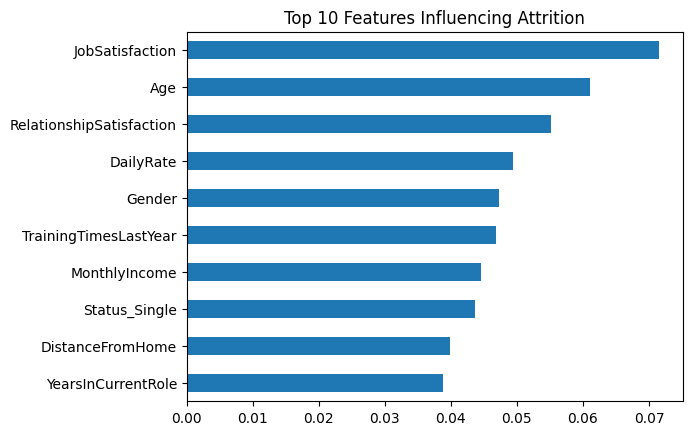

In [51]:
feature_importance.head(10).plot(kind='barh')
plt.title('Top 10 Features Influencing Attrition')
plt.gca().invert_yaxis()
plt.show()

In [54]:
df['Attrition_Probability'] = rf_model.predict_proba(x)[:, 1]

high_risk_employees = df[df['Attrition_Probability'] > 0.7]
high_risk_employees.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,...,Role_Manager,Role_Manufacturing Director,Role_Research Director,Role_Research Scientist,Role_Sales Executive,Role_Sales Representative,Status_Divorced,Status_Married,Status_Single,Attrition_Probability
14,28,1,103,24,3,3,Male,50,2,1,...,0,0,0,0,0,0,0,0,1,0.815
26,32,1,1125,16,1,2,Female,72,1,1,...,0,0,0,1,0,0,0,0,1,0.765
33,39,1,895,5,3,4,Male,56,3,2,...,0,0,0,0,0,1,0,1,0,0.735
34,24,1,813,1,3,2,Male,61,3,1,...,0,0,0,1,0,0,0,1,0,0.710
42,26,1,1357,25,3,1,Male,48,1,1,...,0,0,0,0,0,0,0,0,1,0.840


## Predictions

In [65]:
y_pred = rf_model.predict(x_test)
y_proba = rf_model.predict_proba(x_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.8401360544217688
Precision: 0.5
Recall: 0.06382978723404255
F1 Score: 0.11320754716981132


## Classification Report

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294



## Confusion Matrix

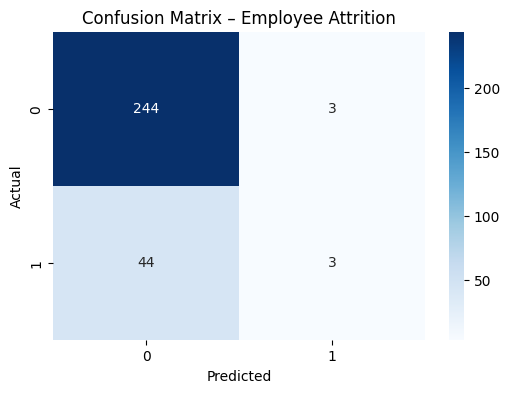

In [67]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix – Employee Attrition")
plt.show()

## Feature Importance

In [68]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importance.head(10)

,Feature,Importance
9,JobSatisfaction,0.071534
0,Age,0.061081
16,RelationshipSatisfaction,0.055130
1,DailyRate,0.049361
5,Gender,0.047340
19,TrainingTimesLastYear,0.046768
10,MonthlyIncome,0.044569
48,Status_Single,0.043666
2,DistanceFromHome,0.039866
22,YearsInCurrentRole,0.038854


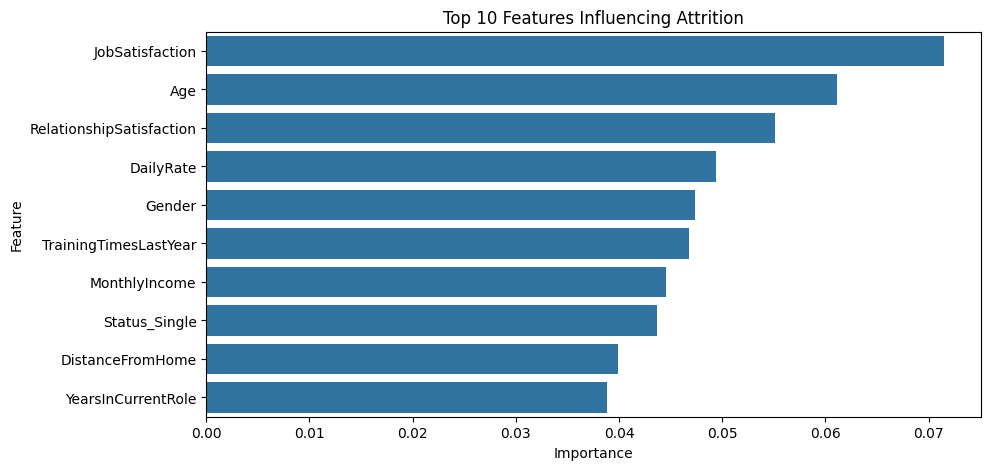

In [69]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)
plt.title("Top 10 Features Influencing Attrition")
plt.show()

In [70]:
feature_importance.head(5)

,Feature,Importance
9,JobSatisfaction,0.071534
0,Age,0.061081
16,RelationshipSatisfaction,0.055130
1,DailyRate,0.049361
5,Gender,0.047340


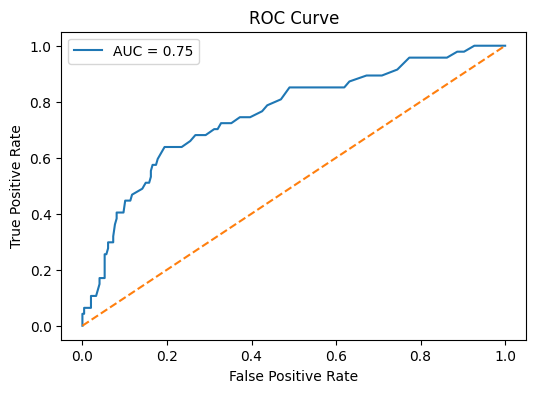

In [71]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()